# Step 4 — Scoring on the official test set

First and only contact with the test set. Everything up to here — the vectorizer's vocabulary, the
IDF weights, the hyperparameter sweep, early stopping — was decided on training and validation data.

In [1]:
import json, numpy as np, tensorflow as tf, matplotlib.pyplot as plt
from scipy import sparse
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix)

X_test = sparse.load_npz("../data/processed/tfidf_test.npz")
y_test = np.load("../data/processed/y_test.npy")
class_names = json.load(open("../data/processed/vocabulary.json"))["class_names"]
model = tf.keras.models.load_model("../data/outputs/nn_tfidf.keras")

y_pred = model.predict(X_test, verbose=0).argmax(axis=1)
print("test set:", X_test.shape[0], "articles")

2026-08-28 18:51:33.237707: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


test set: 50373 articles


## Why macro-F1 is the headline number, not accuracy

The test set is not drawn like the training set — `Doi song` is 9.4% of train but 4.0% of test,
`The gioi` is 8.6% vs 13.3%. A model that quietly learns the training prior gets rewarded or
punished by that shift, and plain accuracy hides it.

The clearest way to see this is what the trivial strategies score:

In [2]:
maj = np.bincount(y_test).argmax()
rng = np.random.default_rng(42)
for name, pred in [("always largest class", np.full_like(y_test, maj)),
                   ("uniform random",       rng.integers(0, 10, len(y_test)))]:
    print(f"{name:22} accuracy={accuracy_score(y_test, pred):.4f}   "
          f"macro-F1={f1_score(y_test, pred, average='macro'):.4f}")

always largest class   accuracy=0.1502   macro-F1=0.0261
uniform random         accuracy=0.1016   macro-F1=0.0977


A model that has learned *nothing* except which class is biggest scores 15% accuracy — high enough
to look like partial learning — while its macro-F1 is 2.6%, which correctly reports that it is
useless. Accuracy hides that failure; macro-F1 does not.

In [3]:
acc  = accuracy_score(y_test, y_pred)
mf1  = f1_score(y_test, y_pred, average="macro")
wf1  = f1_score(y_test, y_pred, average="weighted")
print(f"accuracy     {acc:.4f}")
print(f"macro-F1     {mf1:.4f}")
print(f"weighted-F1  {wf1:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

accuracy     0.9266
macro-F1     0.9087
weighted-F1  0.9259

                  precision    recall  f1-score   support

Chinh tri Xa hoi     0.8578    0.9267    0.8909      7567
        Doi song     0.8259    0.6616    0.7347      2036
        Khoa hoc     0.8609    0.8354    0.8479      2096
      Kinh doanh     0.9431    0.9013    0.9217      5276
       Phap luat     0.9272    0.9110    0.9190      3788
        Suc khoe     0.9363    0.9522    0.9442      5417
        The gioi     0.9617    0.9391    0.9503      6716
        The thao     0.9832    0.9814    0.9823      6667
         Van hoa     0.9311    0.9538    0.9423      6250
         Vi tinh     0.9447    0.9625    0.9535      4560

        accuracy                         0.9266     50373
       macro avg     0.9172    0.9025    0.9087     50373
    weighted avg     0.9266    0.9266    0.9259     50373



## Confusion matrix

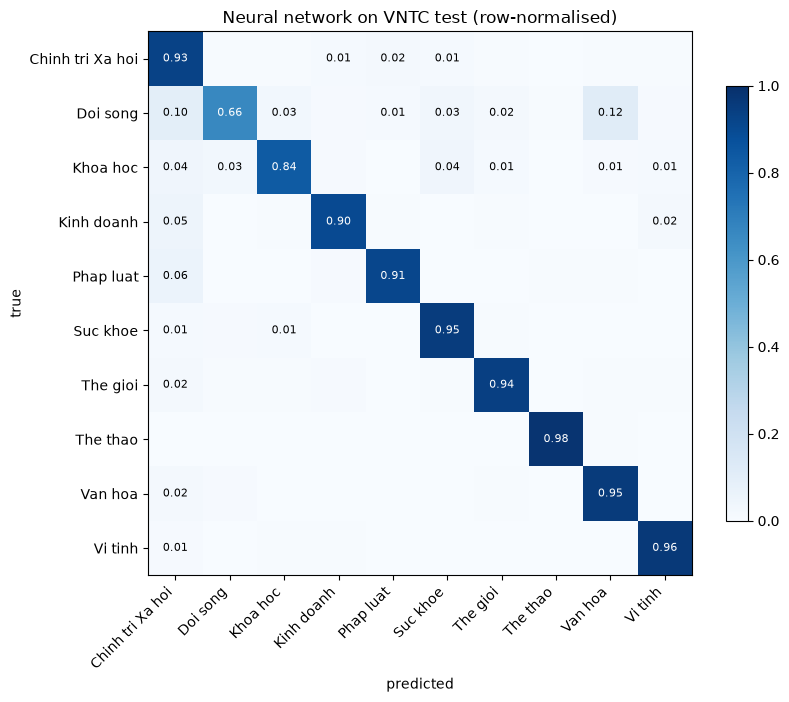

In [4]:
cm  = confusion_matrix(y_test, y_pred)
cmn = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(10), class_names, rotation=45, ha="right")
ax.set_yticks(range(10), class_names)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title("Neural network on VNTC test (row-normalised)")
for i in range(10):
    for j in range(10):
        if cmn[i, j] > 0.01:
            ax.text(j, i, f"{cmn[i,j]:.2f}", ha="center", va="center",
                    fontsize=8, color="white" if cmn[i, j] > 0.5 else "black")
fig.colorbar(im, shrink=.8)
plt.tight_layout(); plt.savefig("../data/outputs/confusion_matrix.png", dpi=110); plt.show()

In [5]:
off = [(cmn[i, j], class_names[i], class_names[j])
       for i in range(10) for j in range(10) if i != j]
print("largest confusions:")
for v, a, b in sorted(off, reverse=True)[:6]:
    print(f"   {v:5.1%}  {a}  ->  {b}")

largest confusions:
   11.6%  Doi song  ->  Van hoa
   10.1%  Doi song  ->  Chinh tri Xa hoi
    6.1%  Phap luat  ->  Chinh tri Xa hoi
    5.1%  Kinh doanh  ->  Chinh tri Xa hoi
    4.3%  Khoa hoc  ->  Suc khoe
    4.1%  Khoa hoc  ->  Chinh tri Xa hoi


## Two caveats that belong next to the number

**The test set leaks into training.** 2,531 test files (5.0%) are byte-identical to a training file.
This is a property of the published corpus, not of this pipeline, and the same inflation applies to
the RIVF'07 baselines the result is compared against — but the number should be read as containing
up to ~5 points of memorisation.

**The ceiling is not 100%.** 219 test files have content identical to another test file filed under
a *different* class, so no model can get both right: maximum achievable accuracy is 99.57%.

In [6]:
json.dump({"accuracy": float(acc), "macro_f1": float(mf1), "weighted_f1": float(wf1),
           "per_class_f1": {c: float(v) for c, v in
                            zip(class_names, f1_score(y_test, y_pred, average=None))},
           "confusion_matrix": cm.tolist()},
          open("../data/outputs/nn_test_metrics.json", "w"), ensure_ascii=False, indent=1)
print("saved")

saved
